# Phys-371 Project - Yusuf Kayra Gül - 22303018
Necessary Libraries

In [55]:
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
from matplotlib.gridspec import GridSpec

## Question and Solution Path 
My project question is asking me to calculate potential in a tetrahedron or in other words it is asking me to solve Laplace Equation in a tetrahedron with constant potentials on the boundary surfaces. Gauss-Seidel Method will be used to solve the question. The full question is as follows.

![Project_Question](PROJECT.png)

In the question it is stated that potential value at the origin can be found analytically and be used to estimate the error. After finding the potential at the origin analytically, the problem should be solved numerically which is quite tricky due to unusual shape of the tetrahedron boundary. There should be found a way to both set the tetrahedron boundary conditions and determine the grid points inside the tetrahedron so that the algorithm can run Gauss-Seidel Method to determine the potential at every point inside the tetrahedron. After determining the potential inside the tetrahedron, np.gradient comment can be used to determine the electric field vector at the origin or for a faster method, since np.gradient runs on all potential, centered derivatives in space can be used at origin to determine the electric field.

## 1) Finding the Potential at the Origin

Since the potential $V(\mathbf{r})$ satisfies Laplace Equation for given boundaries it is a harmonic function and it satisfies Mean Value Property inside the tetrahedron which is for a spherical surface centered at $\mathbf{r_0}$:
$$V(\mathbf{r_0})=\frac{1}{4\pi}\int_{\Omega = 4\pi} V( \mathbf{r_0} + \epsilon \hat{\mathbf{n}})d\Omega$$
Or for any surface $S$ which encloses origin and symmetric around origin:
$$V(0,0,0)=\frac{1}{S}\int_{s} V(\mathbf{r})dS$$
Since in our case the potential along tetrahedron surfaces are constant and tetrahedron is symmetric around origin we choose tetrahedron as $S$:
$$\int_{s} V(\mathbf{r})dS=\Sigma_{i=1}^{4}V_i\int_{S_i}dS$$
Where $V_i$ is the potential on the face $S_i$. So:
$$V(0,0,0)=\frac{\Sigma_{i=1}^{4}V_iS_i}{\Sigma_{i=1}^{4}S_i}$$
Since in our case all $S_i$ are equal:
$$V(0,0,0)=\frac{\Sigma_{i=1}^{4}V_i}{4}=\frac{1 + 2 + 3 + 4}{4}=2.5$$

Since the correct formula uses solid angles instead of surfaces, due to symmetry it does not matter and final potential is given by the direct average of all the surface potentials. So the error will be estimated using analytical value of $V(0,0,0)=2.5$


## 2) Setting the Boundaries and Determining the Points Inside

We have a metal tetrahedron of side $L$ and its four surface are kept at $4V$, $3V$, $2V$, $1V$. The corners of the tetrahedron are given as:

$$A=\frac{L}{2}\left(-1,0,\frac{-1}{\sqrt{2}}\right)\quad B=\frac{L}{2}\left(1,0,\frac{-1}{\sqrt{2}}\right)$$
$$C=\frac{L}{2}\left(0,1,\frac{1}{\sqrt{2}}\right)\quad D=\frac{L}{2}\left(0,-1,\frac{1}{\sqrt{2}}\right)$$

Setting $L=1$ in the code will simplify the whole system and make it applicable to any such system by scaling the results. Also converting points into vectors which represents the vector from origin to points will help us to determine surfaces:

$$\vec{A}=\left(\frac{-1}{2},0,\frac{-1}{2\sqrt{2}}\right)\quad \vec{B}=\left(\frac{1}{2},0,\frac{-1}{2\sqrt{2}}\right)$$
$$\vec{C}=\left(0,\frac{1}{2},\frac{1}{2\sqrt{2}}\right)\quad \vec{D}=\left(0,\frac{-1}{2},\frac{1}{2\sqrt{2}}\right)$$

So the corners of the each face and corresponding voltages are as follows:

$$\text{Face 1:  [B,C,D] - }1V\qquad\text{Face 2:  [A,C,D] - }2V$$

$$\text{Face 3:  [A,B,D] - }3V\qquad\text{Face 4:  [A,B,C] - }4V$$

Or in more general:

$$\text{Face i:} \quad [p_{1i},p_{2i},p_{3i}] - V_i$$

Thus, we can determine the normal vector of each face as follows:

$$\text{Face 1:}\quad\vec{n_1}=(\vec{C}-\vec{B})\times(\vec{D}-\vec{B})\qquad\text{Face 2:}\quad\vec{n_2}=(\vec{C}-\vec{A})\times(\vec{D}-\vec{A})$$

$$\text{Face 3:}\quad\vec{n_3}=(\vec{B}-\vec{A})\times(\vec{D}-\vec{A})\qquad\text{Face 4:}\quad\vec{n_4}=(\vec{B}-\vec{A})\times(\vec{C}-\vec{A})$$

Or again in more general:

$$\text{Face i:}\quad\vec{n_i}=(\vec{p_{2i}}-\vec{p_{1i}})\times(\vec{p_{3i}}-\vec{p_{1i}})$$

Then we could check if normal vector of each face is pointing inside or outside by simply checking the dot product of the reference point of each face. For example for face 1 if $\vec{n_i} \cdot \vec{p_{1i}} < 0$ it means that the normal vector $\vec{n_i}$ is already pointing inside but if $\vec{n_i} \cdot \vec{p_{1i}} > 0$ we could change the direction of normal vector by simply multipliying with $-1$ so in algorithm $\vec{n_i}=-\vec{n_i}$. Repeating this for each face helps us to be make sure every normal vector is pointing inside. We will use these normal vectors to check if any point $r$ is inside the tetrahedron by implementing the condition:

$$\vec{r}\in \text{Tetrahedron} \Longleftrightarrow \vec{n_i}\cdot(\vec{r}-\vec{p_{1i}})\geq 0 \quad \forall i$$

And similarly the points on faces are defined as:

$$\vec{n_i}\cdot(\vec{r}-\vec{p_{1i}}) = 0 $$

These conditions could be checked inside the algorithm, but since our grid is not going to be perfect a tolerance coefficient $\epsilon > 0 : \epsilon\in\mathbb{R} $ will be used such that:

$$\vec{r}\in \text{Tetrahedron} \Longleftrightarrow \vec{n_i}\cdot(\vec{r}-\vec{p_{1i}})\geq -\epsilon \quad \forall i$$

and another tolerance coefficient $\delta > 0 : \delta\in\mathbb{R}$ such that:

$$|\vec{n_i}\cdot(\vec{r}-\vec{p_{1i}})| \leq \delta$$

$\epsilon$ should be choosen such that it is sufficiently small. But $\delta$ should be choosen somewhat proportional to grid spacing $h$ which will discussed next section.

In the algorithm we will implement boundary conditions such that the points satisfying $|\vec{n_i}\cdot(\vec{r}-\vec{p_{1i}})| \leq \epsilon$ will have the potential $V_i$.

After finding if $\vec{r}$ is in the tetrahedron we could check for the smallest $\vec{n_i}\cdot(\vec{r}-\vec{p_{1i}})$ to find the closest face to point $r$. This will be used in Gauss-Seidel Method to determine the which face is crossed when we are taking average for the points close to the faces and with this information the correct $V_i$ will be used.

### Reference
[Algorithms for 3D volumes](https://www.doc.ic.ac.uk/~dfg/graphics/graphics2008/GraphicsLecture04.pdf)

In [60]:
# Setting L=1 as discussed
L = 1.0

# Defining the points
A = 0.5 * L * np.array([-1.0,  0.0, -1/np.sqrt(2.0)])
B = 0.5 * L * np.array([ 1.0,  0.0, -1/np.sqrt(2.0)])
C = 0.5 * L * np.array([ 0.0,  1.0,  1/np.sqrt(2.0)])
D = 0.5 * L * np.array([ 0.0, -1.0,  1/np.sqrt(2.0)])

# Defining the faces as a list contains corners as tuples
face_triples = [
    (B, C, D),  # Face 1
    (A, C, D),  # Face 2
    (A, B, D),  # Face 3
    (A, B, C),  # Face 4
]

# Defining face voltages in correct order with face_triplets
V_face = np.array([1.0,2.0,3.0,4.0])

# Calculating inward normals for each face and storing them into a list as tuples containing normal vector and corresponding p_1
faces = []
for p1, p2, p3 in face_triples:
    n = np.cross(p2 - p1, p3 - p1)
    if np.dot(n, -p1) < 0:  # Checking direction and implementing desired direction
        n = -n
    faces.append((n, p1))

# Defining tolerance coefficient epsilon 
epsilon = 1e-12 

# Defining a function which taking a point r and returning True if the point is inside the volume, False otherwise
def inside_test(x, y, z):
    r = np.array([x,y,z])
    for n, p0 in faces:
        if np.dot(n, r - p0) < -epsilon:
            return False
    return True

# Defining a function which takes a point r and returns the index of the closest surface to that point by finding the smallest n_i·(r-p_1i)
def closest_face_index(x, y, z):
    r = np.array([x,y,z])
    s = [np.dot(n, r - p0) for n, p0 in faces]
    return int(np.argmin(s))


## 3) Creating the Grid and Setting the Boundary Conditions

First, we should choose the smallest cubic volume which can enclose our tetrahedron. Since maximum distance between the points is lies inside a cube with a side length of $\frac{L}{2}$, we can use a cube with those dimensions to put our tetrahedron in. Nevertheless, we cannot create an grid with infinite point so we should limit our points with some parameter $N$ which corresponds to number of points on every axis so in total we will have $N^3$ points to work on and spacing $h$. In other words we will create an cubic grid with finite points in it such that:
$$x_i, y_j, z_k \in \left(\frac{-L}{2},\frac{L}{2}\right)$$
With proper spacing:
$$h=\frac{L}{N-1}$$
After creating the grid, we should set the boundary conditions using the functions we wrote above and two $N^3$ matrices containing boolean values to specify points on surfaces and points inside of the tetrahedron (True for on surface and True for inside, False otherwise).

Also a $N^3$ matrix will be used to store index of the closest surface to every point which will helps us to determine which boundary to use when a point is just at the boundary.

Since our grid is not perfect we will again use a tolerance coefficient $\delta$ which we had discussed previously. After the points inside of the tetrahedron are determined using the functions written above, those points will be again used to check:
$$|\vec{n_i}\cdot(\vec{r}-\vec{p_{1i}})| \leq \delta$$
Then the points satisfies this condition will be counted as the points on surface. Now the question is how to set the appropriate $\delta$.

Since our grid elements are cubes with side length of $h$ it is appropriate to think $\delta$ should be somewhat proporttional to $\frac{h}{2}$ but not directly $\delta=\frac{h}{2}$. To support this claim lets look at our condition again:
$$|\vec{n_i}\cdot(\vec{r}-\vec{p_{1i}})| \leq \delta$$
If the quantity at the left hand side was the real distace between surface and the point $\delta=\frac{h}{2}$ would be valid but left hand side is the distance between point and the plane scaled with area or in other words $||\vec{n_i}||$. Thus scaling $\delta$ with $||\vec{n_i}||$ is the valid tolerance for this system which is $\delta=\frac{h}{2}||\vec{n_i}||$. Now one could ask which $||\vec{n_i}||$ should be used, answer of this question is whichever we want since all areas are equal for our beautifully symmetric tetrahedron. But if it was not symmetric, we should first specify the surface closest to that point and check with appropriate $\delta=\frac{h}{2}||\vec{n_i}||$ where $||\vec{n_i}||$ is the normal vector of the closest surface.

After specifying the surfaces we will implement the corresponding $V_i$'s. Since we know $V(0,0,0)=2.5V$, instead of starting with an random potential distribution we can use $2.5V$ all inside the tetrahedron to slightly fasten our algorithm.

In [63]:
# Creating the grid with an arbitrary N
N = 41
xs = np.linspace(-L/2, L/2, N) #|
ys = np.linspace(-L/2, L/2, N) #| - Creating the axes which lies from -L/2 to L/2 with N points on each
zs = np.linspace(-L/2, L/2, N) #|
h = xs[1] - xs[0]  # Since all axes have the same spacing one of them has choosen to calculate h

# Defining the tolerance coefficient delta as discussed
delta = 0.5*h*np.linalg.norm(faces[0][0])

# The mentioned Boolean N^3 matrices which initially stores all False.
inside = np.zeros((N,N,N), dtype=bool)
onface = np.zeros((N,N,N), dtype=bool)

# The mentioned matrix to hold index of the closest surface. 
# Minus sign is to specify the points outside the tetrahedron, because when the points inside and on the tetrahedron updated they will become positive.
face_index = -np.ones((N,N,N), dtype=int)

# Now lets determine all of the matrices specified with a single nested for loop
for i,x in enumerate(xs):  # Loop to iterate all x-axis
    for j,y in enumerate(ys): # Loop to iterate all y-axis
        for k,z in enumerate(zs):  # Loop to iterate all z-axis
            if inside_test(x,y,z):  # Cheking if the point is inside of the tetrahedron
                inside[i,j,k] = True # Changing the corresponding point to True
                f_index = closest_face_index(x,y,z) # Determining the index of the closest face
                face_index[i,j,k] = f_index # Updating the value of corresponding point from -1 to index of the closest face
                r = np.array([x,y,z]) # Defining r as a vector to compute dot product
                if abs(min([np.dot(n, r - p0) for n,p0 in faces])) < delta: # Cheking the onface condition for every face. 
                #This could be done using just the closest face in current way we can catch the points on corners more easily. 
                    onface[i,j,k] = True # Changing the corresponding point to True
                    
# Now we need to determine which points to update in our Gauss-Seidel Method.
# We should update the points inside of the tetrahedron except the ones on the faces because we should not disturb the boundary conditions.
# So combining inside matrix and logical NOT onface matrix in a way that new matrix has True values for only the points we want to update.
update = inside & (~onface)

# Construct the N^3 potential grid with discussed conditions
V = np.full((N,N,N), np.nan, dtype=float)  # Assign all values to np.nan which is basically nothing. An empty N^3 grid
V[inside] = 2.5  # Using the boolean inside matrix assign 2.5V to all of the points inside the tetrahedron
# Using boolean onface matrix and V_face list which stores the boundary potentials with corresponding order to faces, 
# assign appropriate potentials to faces. 
V[onface] = V_face[face_index[onface]]

We created the initial potential with appropriate boundary conditions but lets plot it in 3D using scatter to see is it really a tetrahedron.

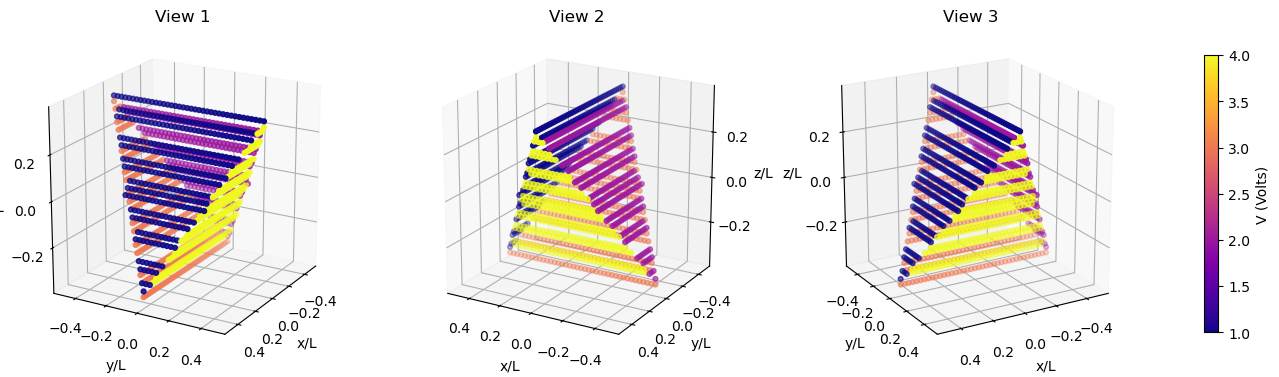

In [66]:
# Get boundary indices
index = np.argwhere(onface & inside)

# Converting indices into coordinates
X = xs[index[:,0]]
Y = ys[index[:,1]]
Z = zs[index[:,2]]

# getting Corresponding potentials
V_values = V[index[:,0], index[:,1], index[:,2]]

fig = plt.figure(figsize=(18,6))

views = [(20,30), (20,120), (20,60)]
titles = ["View 1", "View 2", "View 3"]

for i, ((elev, azim), title) in enumerate(zip(views, titles), start=1):
    ax = fig.add_subplot(1, 3, i, projection="3d")
    sc = ax.scatter(X, Y, Z, c=V_values, cmap="plasma", s=12)
    ax.view_init(elev=elev, azim=azim)

    # Conserving the geometry proportions
    try:
        ax.set_box_aspect((1,1,1))
    except Exception:
        pass

    ax.set_title(title)
    ax.set_xlabel("x/L")
    ax.set_ylabel("y/L")
    ax.set_zlabel("z/L")
    
# Setting the colorbar specifying the potential
cbar = fig.colorbar(sc, ax=fig.axes, shrink=0.6)
cbar.set_label("V (Volts)")

plt.show()

As it could be seen the boundary conditions are implemented succesfully. Although there are some imperfections on the boundaries, these imperfections will be handeled in the next section.

## 4) Implementing Gauss-Seidel Method and Convergence Criteriion

A standart Gauss-Seidel algorithm without relaxation will be used to calculate potential. There is no need an relaxation since the method works really well with relatively small $N$ and quite fast.

To determine the points which will be updated, the boolean matrix "update" will be used. But the problem is some neighbors of the some of the points may lie outside of the tetrahedron or lie on the imperfect regions of boundaries. To handle this issue we will check the neighbors of the current point and if it is on the face or outside the tetrahedron we will use "face_index" matrix to determine closest face and use the boundary potential on that face instead of the problematic neighbor. By this way we will also be handled the imperfections on the boundaries. This algorithm will iterate until it hits a maximum number of iterations or the convergence criterion is satisfied.

As convergence criterion we will calculate the max change between the old potential and the currently calculated potential. This max change will be compared with an tolerance value, which will be set arbitrarly, and when the desired tolerance reached the potential will be accepted as converged.

In [70]:
tolerance = 1e-10  # Define the desired tolerance
max_iterations = 5000  # Maximum number of iteration        

# Neighbor directions in index notation (di,dj,dk)
directions = [(1,0,0),(-1,0,0),(0,1,0),(0,-1,0),(0,0,1),(0,0,-1)]

for iteration_number in range(max_iterations):
    max_change = 0.0  # Initially define max_change=0 to be updated later 

    # Gauss–Seidel iterate over all update points
    update_index = np.argwhere(update)  # Determine the indexes of update points
    for (i,j,k) in update_index:  # Start a for loop using indexes of update points
        x, y, z = xs[i], ys[j], zs[k]

        V_sum = 0.0  # Initially set the summation of neighbor potentials to 0 and update in the for loop below
        for di,dj,dk in directions: # Take the neighbor directions one by one to check neighbors seperately
            ii, jj, kk = i+di, j+dj, k+dk  # Define new indexes by updating them with directions
            if 0 <= ii < N and 0 <= jj < N and 0 <= kk < N and inside[ii,jj,kk]:  # Check if neighbors inside the grid and inside the tetrahedron
                # Neighbor inside tetrahedron use grid value (boundary or interior)
                V_sum += V[ii,jj,kk]  # Add potential on neighbor to summation
            else:  # Problematic neighbor
                # Neighbor outside or on the tetrathedron use face voltage
                V_sum += V_face[face_index[i,j,k]]  # Add potential on nearest face to summation
        
        V_new = V_sum/6.0  # Taking the average 
        V_old = V[i,j,k]  # Taking the old value at current point to compare

        change = abs(V_new - V_old) 
        if change > max_change:  # Find the maximum change
            max_change = change

        V[i,j,k] = V_new  # Update the value on main potential

    if max_change < tolerance:  # Convergence Criterion
        print(f"Converged at iter {iteration_number+1}, max_change={max_change:.3e}")
        break
        
else:  # Notify if the convergence criterion is failed to be satisfied in specified maximum number of iterations
    print(f"Reached max_iters={max_iterations}, last max_change={max_change:.3e}")

Converged at iter 540, max_change=9.795e-11


## 5) Results and Plots

Since we calculated the whole potential, we could print and compare the potential at the origin $V(0,0,0)$ and compare it with the analytical value $V(0,0,0)=2.5V$. 

For the electric field vector, one could use np.gradient($V$) and find the components at origin but since there is a probability that $N$ is large thus $N^3$ is vastly large. In that condition calculating the gradient over whole potential just to find electric field at origin is inefficient. Thus, we will use centered derivatives for each component at origin to calculate electric field. Since:
$$\vec{E}=-\vec{\nabla}V$$
We can say that:
$$E_x(0,0,0)=\left(-\frac{\partial V}{\partial x}\right)_{(0,0,0)} \qquad E_y(0,0,0)=\left(-\frac{\partial V}{\partial y}\right)_{(0,0,0)} \qquad E_z(0,0,0)=\left(-\frac{\partial V}{\partial z}\right)_{(0,0,0)}$$
Which could be discretized with centered derivatives as:
$$E_x(0,0,0)\cong-\frac{V(\Delta x,0,0)+V(-\Delta x,0,0)}{2\Delta x} \quad E_y(0,0,0)\cong-\frac{V(0,\Delta y,0)+V(0,-\Delta x,0)}{2\Delta y} \quad E_z(0,0,0)\cong-\frac{V(0,0,\Delta z)+V(0,0,-\Delta z)}{2\Delta z}$$
Ofcourse in our case $\Delta x=\Delta y=\Delta z=h$.

For the plots in $x-z$ and $y-z$ planes we will simply plot $V(x,0,z)$ and $V(0,y,z)$ in different ways to visualize the data as good as possible.

Numerical V(0) = 2.4991358708980127 (analytic check: 2.5)
Percentage error in potential: %0.03456516407949195
E(0) = (1.8587867296918132, -1.858786725907578, 5.207732448676272)


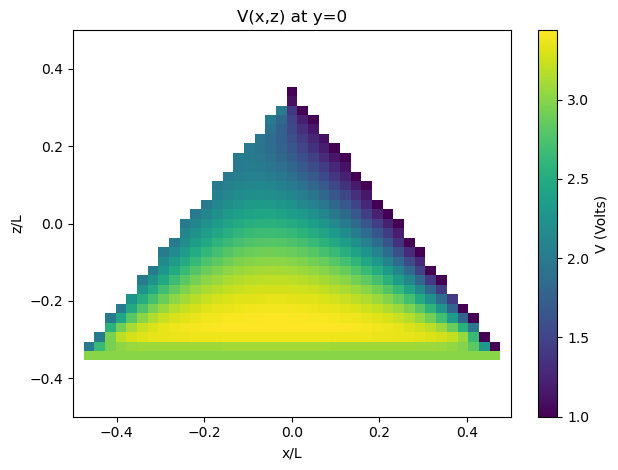

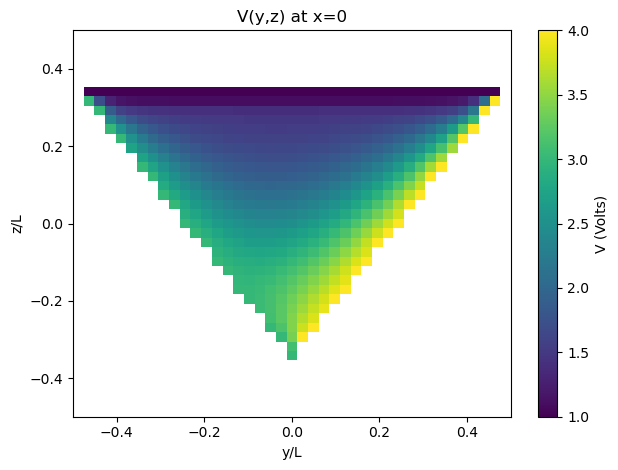

In [72]:
# Extracting the indexes of desired point (0,0,0) which is the minimum absolute value in the x, y and z axes.
ix0 = np.argmin(np.abs(xs))
iy0 = np.argmin(np.abs(ys))
iz0 = np.argmin(np.abs(zs))

# Determine V(0,0,0) using the determined indexes
V0 = V[ix0,iy0,iz0]
print(f"Numerical V(0) = {V0} (analytic check: 2.5)")
print(f"Percentage error in potential: %{(np.abs(V0 - 2.5)/2.5)*100}")

# Calculating E_x, E_y, E_z with centered derivatives and printing
Ex = -(V[ix0+1,iy0,iz0] - V[ix0-1,iy0,iz0])/(2*h)
Ey = -(V[ix0,iy0+1,iz0] - V[ix0,iy0-1,iz0])/(2*h)
Ez = -(V[ix0,iy0,iz0+1] - V[ix0,iy0,iz0-1])/(2*h)
print(f"E(0) = {Ex,Ey,Ez}")

# Plotting V(x,z) at y=0 and V(y,z) at x=0 as colored plots
plt.figure()
plt.title("V(x,z) at y=0")
plt.imshow(V[:,iy0,:].T, origin="lower",
           extent=[xs[0],xs[-1],zs[0],zs[-1]],
           aspect="auto")
plt.xlabel("x/L")
plt.ylabel("z/L")
plt.colorbar(label="V (Volts)")
plt.tight_layout()

plt.figure()
plt.title("V(y,z) at x=0")
plt.imshow(V[ix0,:,:].T, origin="lower",
           extent=[ys[0],ys[-1],zs[0],zs[-1]],
           aspect="auto")
plt.xlabel("y/L") 
plt.ylabel("z/L")
plt.colorbar(label="V (Volts)")
plt.tight_layout()


plt.show()

## Results for $N=41$

In conclusion, Gauss-Seidel method has succesfully implemented to given problem. The biggest challenge was to implement the boundary conditions which is a tetrahedron but this has succeeded using appropriate vector algebra and tolerance coefficients. Even though we used appropriate techniques to implement boundary conditions there still is a slight error due to imperfections on boundary conditions. For $N=41$, it seem to be converging to $V(0,0,0)=2.499136V$. One could say that with increasing iteration number it could be handled but even with the wast iteration numbers it still converges to $V(0,0,0)=2.499136V$. To confirm this lets run the algorithm for $1000$ iteration with same $N=41$ and observe the results.

Reached max_iters=1000, last max_change=0.000e+00
Numerical V(0) = 2.4991358679831177 (analytic check: 2.5)
Percentage error in potential: %0.03456528067529163
E(0) = (1.8587867277997179, -1.8587867277997356, 5.207732446783102)


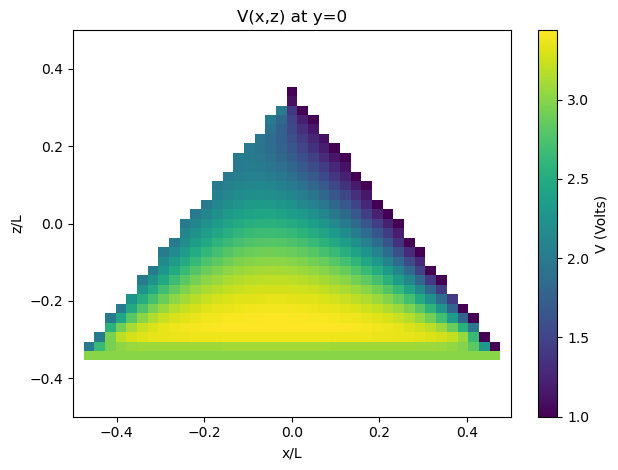

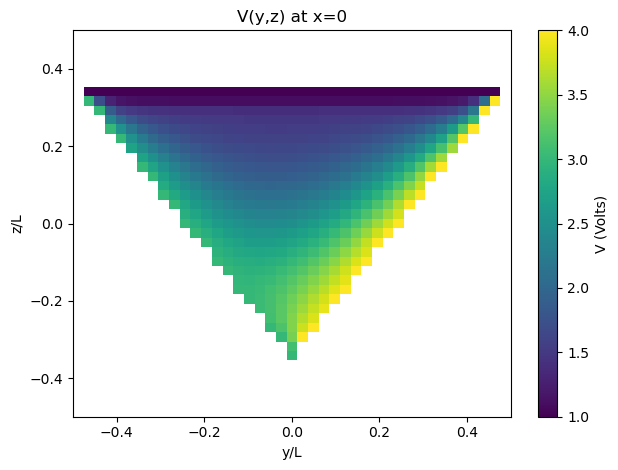

In [47]:
max_iterations = 1000  # max_iterations will be used as exact number of iteration        

# Neighbor directions in index notation (di,dj,dk)
directions = [(1,0,0),(-1,0,0),(0,1,0),(0,-1,0),(0,0,1),(0,0,-1)]

for iteration_number in range(max_iterations):
    max_change = 0.0  # Initially define max_change=0 to be updated later 

    # Gauss–Seidel iterate over all update points
    update_index = np.argwhere(update)  # Determine the indexes of update points
    for (i,j,k) in update_index:  # Start a for loop using indexes of update points
        x, y, z = xs[i], ys[j], zs[k]

        V_sum = 0.0  # Initially set the summation of neighbor potentials to 0 and update in the for loop below
        for di,dj,dk in directions: # Take the neighbor directions one by one to check neighbors seperately
            ii, jj, kk = i+di, j+dj, k+dk  # Define new indexes by updating them with directions
            if 0 <= ii < N and 0 <= jj < N and 0 <= kk < N and inside[ii,jj,kk]:  # Check if neighbors inside the grid and inside the tetrahedron
                # Neighbor inside tetrahedron use grid value (boundary or interior)
                V_sum += V[ii,jj,kk]  # Add potential on neighbor to summation
            else:  # Problematic neighbor
                # Neighbor outside or on the tetrathedron use face voltage
                V_sum += V_face[face_index[i,j,k]]  # Add potential on nearest face to summation
        
        V_new = V_sum/6.0  # Taking the average 
        V_old = V[i,j,k]  # Taking the old value at current point to compare

        change = abs(V_new - V_old) 
        if change > max_change:  # Find the maximum change
            max_change = change

        V[i,j,k] = V_new  # Update the value on main potential
        
print(f"Reached max_iters={max_iterations}, last max_change={max_change:.3e}")

# Extracting the indexes of desired point (0,0,0) which is the minimum absolute value in the x, y and z axes.
ix0 = np.argmin(np.abs(xs))
iy0 = np.argmin(np.abs(ys))
iz0 = np.argmin(np.abs(zs))

# Determine V(0,0,0) using the determined indexes
V0 = V[ix0,iy0,iz0]
print(f"Numerical V(0) = {V0} (analytic check: 2.5)")
print(f"Percentage error in potential: %{(np.abs(V0 - 2.5)/2.5)*100}")

# Calculating E_x, E_y, E_z with centered derivatives and printing
Ex = -(V[ix0+1,iy0,iz0] - V[ix0-1,iy0,iz0])/(2*h)
Ey = -(V[ix0,iy0+1,iz0] - V[ix0,iy0-1,iz0])/(2*h)
Ez = -(V[ix0,iy0,iz0+1] - V[ix0,iy0,iz0-1])/(2*h)
print(f"E(0) = {Ex,Ey,Ez}")

# Plotting V(x,z) at y=0 and V(y,z) at x=0 as colored plots
plt.figure()
plt.title("V(x,z) at y=0")
plt.imshow(V[:,iy0,:].T, origin="lower",
           extent=[xs[0],xs[-1],zs[0],zs[-1]],
           aspect="auto")
plt.xlabel("x/L")
plt.ylabel("z/L")
plt.colorbar(label="V (Volts)")
plt.tight_layout()

plt.figure()
plt.title("V(y,z) at x=0")
plt.imshow(V[ix0,:,:].T, origin="lower",
           extent=[ys[0],ys[-1],zs[0],zs[-1]],
           aspect="auto")
plt.xlabel("y/L") 
plt.ylabel("z/L")
plt.colorbar(label="V (Volts)")
plt.tight_layout()


plt.show()

As expected potential at the origin still converging the same value even with 1000 iterations. Lets try it for $N=61$ with same convergence criterion in the main solution to see if it is getting better.

## Results for $N=61$

Converged at iter 1151, max_change=9.866e-11
Numerical V(0) = 2.4996918379780637 (analytic check: 2.5)
Percentage error in potential: %0.012326480877451475
E(0) = (1.8378516843182484, -1.8378516784857006, 5.167863059896841)


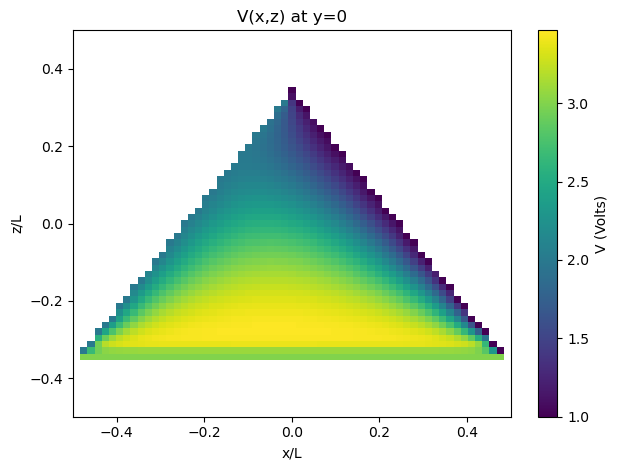

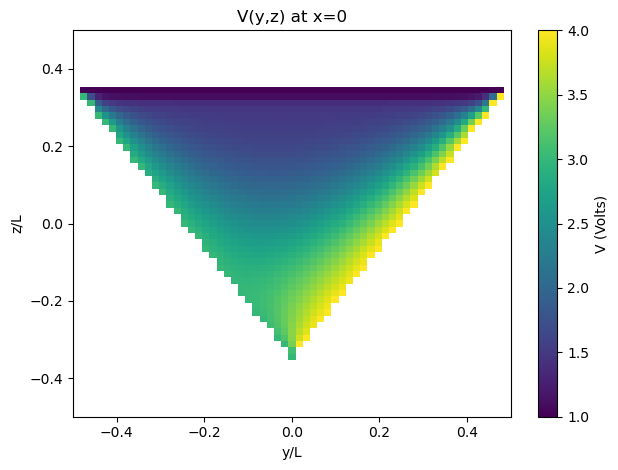

In [74]:
# Creating the grid with an arbitrary N
N = 61
xs = np.linspace(-L/2, L/2, N) #|
ys = np.linspace(-L/2, L/2, N) #| - Creating the axes which lies from -L/2 to L/2 with N points on each
zs = np.linspace(-L/2, L/2, N) #|
h = xs[1] - xs[0]  # Since all axes have the same spacing one of them has choosen to calculate h

# Defining the tolerance coefficient delta as discussed
delta = 0.5*h*np.linalg.norm(faces[0][0])

# The mentioned Boolean N^3 matrices which initially stores all False.
inside = np.zeros((N,N,N), dtype=bool)
onface = np.zeros((N,N,N), dtype=bool)

# The mentioned matrix to hold index of the closest surface. 
# Minus sign is to specify the points outside the tetrahedron, because when the points inside and on the tetrahedron updated they will become positive.
face_index = -np.ones((N,N,N), dtype=int)

# Now lets determine all of the matrices specified with a single nested for loop
for i,x in enumerate(xs):  # Loop to iterate all x-axis
    for j,y in enumerate(ys): # Loop to iterate all y-axis
        for k,z in enumerate(zs):  # Loop to iterate all z-axis
            if inside_test(x,y,z):  # Cheking if the point is inside of the tetrahedron
                inside[i,j,k] = True # Changing the corresponding point to True
                f_index = closest_face_index(x,y,z) # Determining the index of the closest face
                face_index[i,j,k] = f_index # Updating the value of corresponding point from -1 to index of the closest face
                r = np.array([x,y,z]) # Defining r as a vector to compute dot product
                if abs(min([np.dot(n, r - p0) for n,p0 in faces])) < delta: # Cheking the onface condition for every face. 
                #This could be done using just the closest face in current way we can catch the points on corners more easily. 
                    onface[i,j,k] = True # Changing the corresponding point to True
                    
# Now we need to determine which points to update in our Gauss-Seidel Method.
# We should update the points inside of the tetrahedron except the ones on the faces because we should not disturb the boundary conditions.
# So combining inside matrix and logical NOT onface matrix in a way that new matrix has True values for only the points we want to update.
update = inside & (~onface)

# Construct the N^3 potential grid with discussed conditions
V = np.full((N,N,N), np.nan, dtype=float)  # Assign all values to np.nan which is basically nothing. An empty N^3 grid
V[inside] = 2.5  # Using the boolean inside matrix assign 2.5V to all of the points inside the tetrahedron
# Using boolean onface matrix and V_face list which stores the boundary potentials with corresponding order to faces, 
# assign appropriate potentials to faces. 
V[onface] = V_face[face_index[onface]]

tolerance = 1e-10  # Define the desired tolerance same as N=41 case
max_iterations = 5000  # Maximum number of iteration        

# Neighbor directions in index notation (di,dj,dk)
directions = [(1,0,0),(-1,0,0),(0,1,0),(0,-1,0),(0,0,1),(0,0,-1)]

for iteration_number in range(max_iterations):
    max_change = 0.0  # Initially define max_change=0 to be updated later 

    # Gauss–Seidel iterate over all update points
    update_index = np.argwhere(update)  # Determine the indexes of update points
    for (i,j,k) in update_index:  # Start a for loop using indexes of update points
        x, y, z = xs[i], ys[j], zs[k]

        V_sum = 0.0  # Initially set the summation of neighbor potentials to 0 and update in the for loop below
        for di,dj,dk in directions: # Take the neighbor directions one by one to check neighbors seperately
            ii, jj, kk = i+di, j+dj, k+dk  # Define new indexes by updating them with directions
            if 0 <= ii < N and 0 <= jj < N and 0 <= kk < N and inside[ii,jj,kk]:  # Check if neighbors inside the grid and inside the tetrahedron
                # Neighbor inside tetrahedron use grid value (boundary or interior)
                V_sum += V[ii,jj,kk]  # Add potential on neighbor to summation
            else:  # Problematic neighbor
                # Neighbor outside or on the tetrathedron use face voltage
                V_sum += V_face[face_index[i,j,k]]  # Add potential on nearest face to summation
        
        V_new = V_sum/6.0  # Taking the average 
        V_old = V[i,j,k]  # Taking the old value at current point to compare

        change = abs(V_new - V_old) 
        if change > max_change:  # Find the maximum change
            max_change = change

        V[i,j,k] = V_new  # Update the value on main potential

    if max_change < tolerance:  # Convergence Criterion
        print(f"Converged at iter {iteration_number+1}, max_change={max_change:.3e}")
        break
        
else:  # Notify if the convergence criterion is failed to be satisfied in specified maximum number of iterations
    print(f"Reached max_iters={max_iterations}, last max_change={max_change:.3e}")

# Extracting the indexes of desired point (0,0,0) which is the minimum absolute value in the x, y and z axes.
ix0 = np.argmin(np.abs(xs))
iy0 = np.argmin(np.abs(ys))
iz0 = np.argmin(np.abs(zs))

# Determine V(0,0,0) using the determined indexes
V0 = V[ix0,iy0,iz0]
print(f"Numerical V(0) = {V0} (analytic check: 2.5)")
print(f"Percentage error in potential: %{(np.abs(V0 - 2.5)/2.5)*100}")

# Calculating E_x, E_y, E_z with centered derivatives and printing
Ex = -(V[ix0+1,iy0,iz0] - V[ix0-1,iy0,iz0])/(2*h)
Ey = -(V[ix0,iy0+1,iz0] - V[ix0,iy0-1,iz0])/(2*h)
Ez = -(V[ix0,iy0,iz0+1] - V[ix0,iy0,iz0-1])/(2*h)
print(f"E(0) = {Ex,Ey,Ez}")

# Plotting V(x,z) at y=0 and V(y,z) at x=0 as colored plots
plt.figure()
plt.title("V(x,z) at y=0")
plt.imshow(V[:,iy0,:].T, origin="lower",
           extent=[xs[0],xs[-1],zs[0],zs[-1]],
           aspect="auto")
plt.xlabel("x/L")
plt.ylabel("z/L")
plt.colorbar(label="V (Volts)")
plt.tight_layout()

plt.figure()
plt.title("V(y,z) at x=0")
plt.imshow(V[ix0,:,:].T, origin="lower",
           extent=[ys[0],ys[-1],zs[0],zs[-1]],
           aspect="auto")
plt.xlabel("y/L") 
plt.ylabel("z/L")
plt.colorbar(label="V (Volts)")
plt.tight_layout()


plt.show()

As it could be seen it converged to $V(0,0,0)=2.499692V$ for $N=61$. This shows that as we increase the number of points in the grid, the imperfections of the boundaries becomes less and less important and the result approaches to analytic solution. One could try the algorithm with same convergence criterion but even more $N$. Nevertheless, even for $N=61$ the algorithm takes so much time and number of points increases with $N^3$ so more grid points means even more computation times.

## 6) Conclusion

Imperfections in the boundaries are affecting the result slightly but increasing the number of grid points helps us the approach to the exact solution. In conclusion, we could implement the tetrahedron boundary conditions with some defects and solve the Laplace Equation with those boundaries. The results acquired are sufficiently precise, $%0.03$ error, so we can say that the project completed succesfully.

## Extra - Interesting Difference in Results for Odd N and Even N

### For Odd N=21

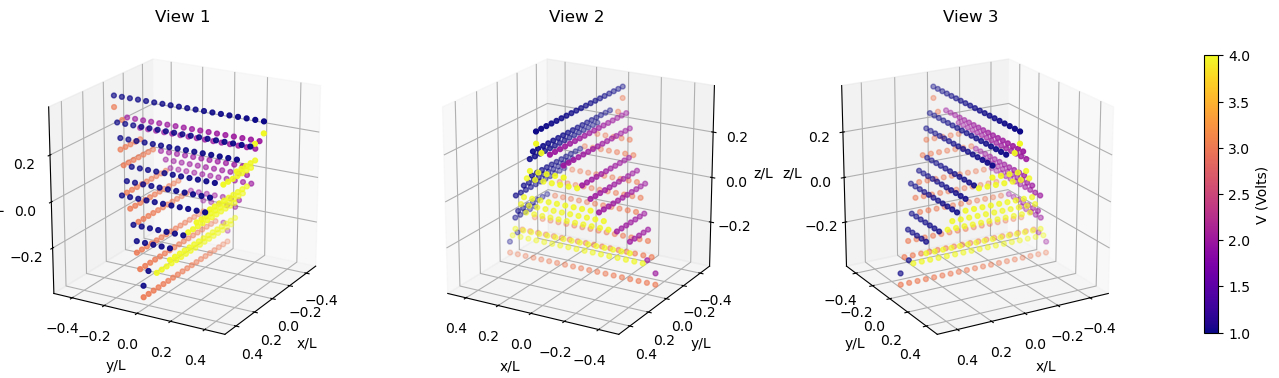

Converged at iter 49, max_change=4.371e-05
Numerical V(0) = 2.495405936465237 (analytic check: 2.5)
Percentage error in potential: %0.1837625413905286
E(0) = (1.9349753373408878, -1.9342282432855389, 5.485039971288846)


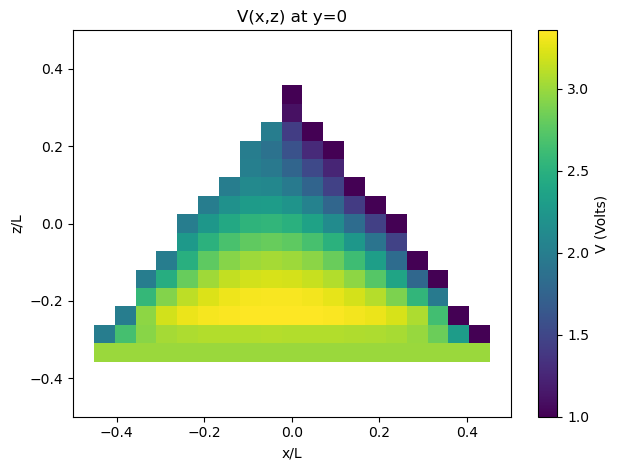

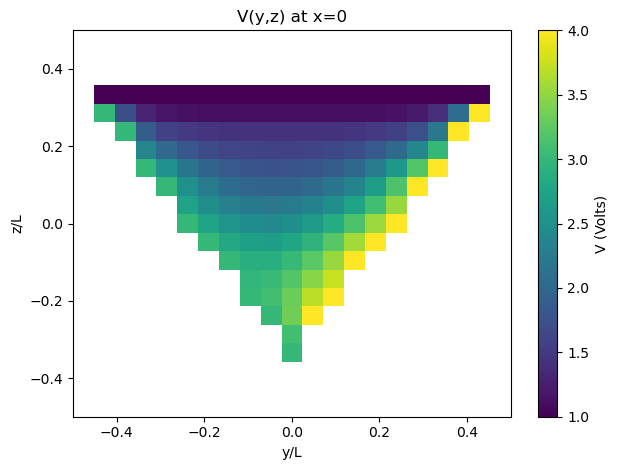

In [9]:
# Creating the grid with an odd N
N = 21
xs = np.linspace(-L/2, L/2, N) #|
ys = np.linspace(-L/2, L/2, N) #| - Creating the axes which lies from -L/2 to L/2 with N points on each
zs = np.linspace(-L/2, L/2, N) #|
h = xs[1] - xs[0]  # Since all axes have the same spacing one of them has choosen to calculate h

# Defining the tolerance coefficient delta as discussed
delta = 0.5*h*np.linalg.norm(faces[0][0])

# The mentioned Boolean N^3 matrices which initially stores all False.
inside = np.zeros((N,N,N), dtype=bool)
onface = np.zeros((N,N,N), dtype=bool)

# The mentioned matrix to hold index of the closest surface. 
# Minus sign is to specify the points outside the tetrahedron, because when the points inside and on the tetrahedron updated they will become positive.
face_index = -np.ones((N,N,N), dtype=int)

# Now lets determine all of the matrices specified with a single nested for loop
for i,x in enumerate(xs):  # Loop to iterate all x-axis
    for j,y in enumerate(ys): # Loop to iterate all y-axis
        for k,z in enumerate(zs):  # Loop to iterate all z-axis
            if inside_test(x,y,z):  # Cheking if the point is inside of the tetrahedron
                inside[i,j,k] = True # Changing the corresponding point to True
                f_index = closest_face_index(x,y,z) # Determining the index of the closest face
                face_index[i,j,k] = f_index # Updating the value of corresponding point from -1 to index of the closest face
                r = np.array([x,y,z]) # Defining r as a vector to compute dot product
                if abs(min([np.dot(n, r - p0) for n,p0 in faces])) < delta: # Cheking the onface condition for every face. 
                #This could be done using just the closest face in current way we can catch the points on corners more easily. 
                    onface[i,j,k] = True # Changing the corresponding point to True
                    
# Now we need to determine which points to update in our Gauss-Seidel Method.
# We should update the points inside of the tetrahedron except the ones on the faces because we should not disturb the boundary conditions.
# So combining inside matrix and logical NOT onface matrix in a way that new matrix has True values for only the points we want to update.
update = inside & (~onface)

# Construct the N^3 potential grid with discussed conditions
V = np.full((N,N,N), np.nan, dtype=float)  # Assign all values to np.nan which is basically nothing. An empty N^3 grid
V[inside] = 2.5  # Using the boolean inside matrix assign 2.5V to all of the points inside the tetrahedron
# Using boolean onface matrix and V_face list which stores the boundary potentials with corresponding order to faces, 
# assign appropriate potentials to faces. 
V[onface] = V_face[face_index[onface]]
# Get boundary indices
index = np.argwhere(onface)

# Converting indices into coordinates
X = xs[index[:,0]]
Y = ys[index[:,1]]
Z = zs[index[:,2]]

# getting Corresponding potentials
V_values = V[index[:,0], index[:,1], index[:,2]]

fig = plt.figure(figsize=(18,6))

views = [(20,30), (20,120), (20,60)]
titles = ["View 1", "View 2", "View 3"]

for i, ((elev, azim), title) in enumerate(zip(views, titles), start=1):
    ax = fig.add_subplot(1, 3, i, projection="3d")
    sc = ax.scatter(X, Y, Z, c=V_values, cmap="plasma", s=12)
    ax.view_init(elev=elev, azim=azim)

    # Conserving the geometry proportions
    try:
        ax.set_box_aspect((1,1,1))
    except Exception:
        pass

    ax.set_title(title)
    ax.set_xlabel("x/L")
    ax.set_ylabel("y/L")
    ax.set_zlabel("z/L")
    
# Setting the colorbar specifying the potential
cbar = fig.colorbar(sc, ax=fig.axes, shrink=0.6)
cbar.set_label("V (Volts)")

plt.show()

tolerance = 5e-5  # Define the desired tolerance
max_iterations = 2000  #         

# Neighbor directions in index notation (di,dj,dk)
directions = [(1,0,0),(-1,0,0),(0,1,0),(0,-1,0),(0,0,1),(0,0,-1)]

for iteration_number in range(max_iterations):
    max_change = 0.0  # Initially define max_change=0 to be updated later 

    # Gauss–Seidel iterate over all update points
    update_index = np.argwhere(update)  # Determine the indexes of update points
    for (i,j,k) in update_index:  # Start a for loop using indexes of update points
        x, y, z = xs[i], ys[j], zs[k]

        V_sum = 0.0  # Initially set the summation of neighbor potentials to 0 and update in the for loop below
        for di,dj,dk in directions: # Take the neighbor directions one by one to check neighbors seperately
            ii, jj, kk = i+di, j+dj, k+dk  # Define new indexes by updating them with directions
            if 0 <= ii < N and 0 <= jj < N and 0 <= kk < N and inside[ii,jj,kk]:  # Check if neighbors inside the grid and inside the tetrahedron
                # Neighbor inside tetrahedron use grid value (boundary or interior)
                V_sum += V[ii,jj,kk]  # Add potential on neighbor to summation
            else:  # Problematic neighbor
                # Neighbor outside or on the tetrathedron use face voltage
                V_sum += V_face[face_index[i,j,k]]  # Add potential on nearest face to summation
        
        V_new = V_sum/6.0  # Taking the average 
        V_old = V[i,j,k]  # Taking the old value at current point to compare

        change = abs(V_new - V_old) 
        if change > max_change:  # Find the maximum change
            max_change = change

        V[i,j,k] = V_new  # Update the value on main potential

    if max_change < tolerance:  # Convergence Criterion
        print(f"Converged at iter {iteration_number+1}, max_change={max_change:.3e}")
        break
        
else:  # Notify if the convergence criterion is failed to be satisfied in specified maximum number of iterations
    print(f"Reached max_iters={max_iterations}, last max_change={max_change:.3e}")

# Extracting the indexes of desired point (0,0,0) which is the minimum absolute value in the x, y and z axes.
ix0 = np.argmin(np.abs(xs))
iy0 = np.argmin(np.abs(ys))
iz0 = np.argmin(np.abs(zs))

# Determine V(0,0,0) using the determined indexes
V0 = V[ix0,iy0,iz0]
print(f"Numerical V(0) = {V0} (analytic check: 2.5)")
print(f"Percentage error in potential: %{(np.abs(V0 - 2.5)/2.5)*100}")

# Calculating E_x, E_y, E_z with centered derivatives and printing
Ex = -(V[ix0+1,iy0,iz0] - V[ix0-1,iy0,iz0])/(2*h)
Ey = -(V[ix0,iy0+1,iz0] - V[ix0,iy0-1,iz0])/(2*h)
Ez = -(V[ix0,iy0,iz0+1] - V[ix0,iy0,iz0-1])/(2*h)
print(f"E(0) = {Ex,Ey,Ez}")

# Plotting V(x,z) at y=0 and V(y,z) at x=0 as colored plots
plt.figure()
plt.title("V(x,z) at y=0")
plt.imshow(V[:,iy0,:].T, origin="lower",
           extent=[xs[0],xs[-1],zs[0],zs[-1]],
           aspect="auto")
plt.xlabel("x/L")
plt.ylabel("z/L")
plt.colorbar(label="V (Volts)")
plt.tight_layout()

plt.figure()
plt.title("V(y,z) at x=0")
plt.imshow(V[ix0,:,:].T, origin="lower",
           extent=[ys[0],ys[-1],zs[0],zs[-1]],
           aspect="auto")
plt.xlabel("y/L") 
plt.ylabel("z/L")
plt.colorbar(label="V (Volts)")
plt.tight_layout()


plt.show()

### For Even N=42

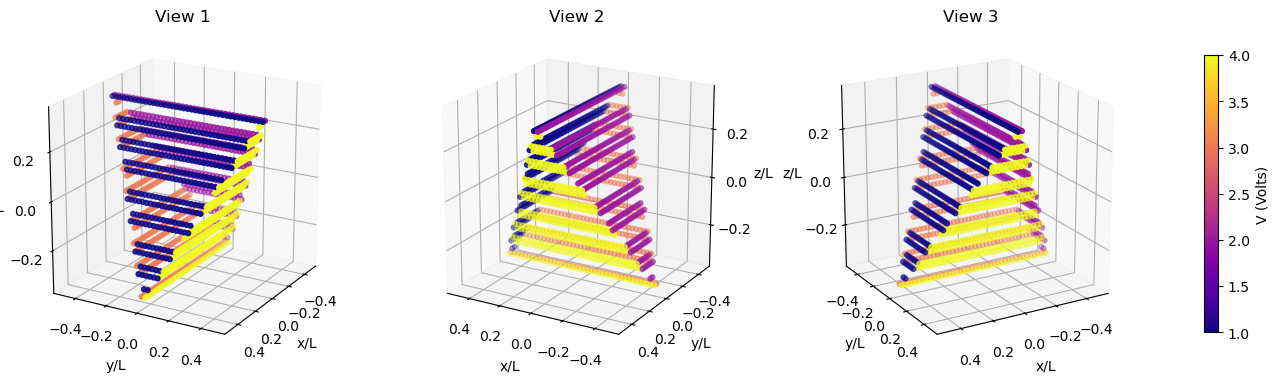

Converged at iter 149, max_change=4.870e-05
Numerical V(0) = 2.562304624495161 (analytic check: 2.5)
Percentage error in potential: %2.492184979806442
E(0) = (1.367299550461085, -1.6092777297775323, 4.965333005263604)


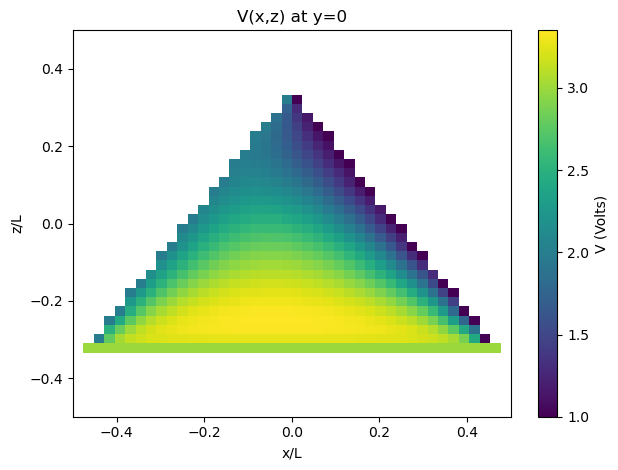

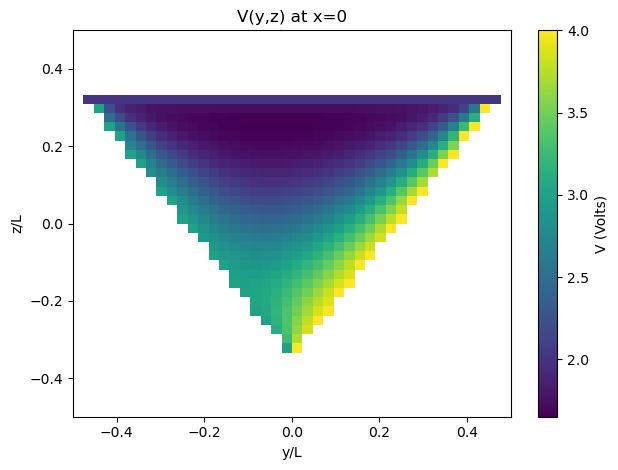

In [55]:
# Creating the grid with an even N
N = 42
xs = np.linspace(-L/2, L/2, N) #|
ys = np.linspace(-L/2, L/2, N) #| - Creating the axes which lies from -L/2 to L/2 with N points on each
zs = np.linspace(-L/2, L/2, N) #|
h = xs[1] - xs[0]  # Since all axes have the same spacing one of them has choosen to calculate h

# Defining the tolerance coefficient delta as discussed
delta = 0.5*h*np.linalg.norm(faces[0][0])

# The mentioned Boolean N^3 matrices which initially stores all False.
inside = np.zeros((N,N,N), dtype=bool)
onface = np.zeros((N,N,N), dtype=bool)

# The mentioned matrix to hold index of the closest surface. 
# Minus sign is to specify the points outside the tetrahedron, because when the points inside and on the tetrahedron updated they will become positive.
face_index = -np.ones((N,N,N), dtype=int)

# Now lets determine all of the matrices specified with a single nested for loop
for i,x in enumerate(xs):  # Loop to iterate all x-axis
    for j,y in enumerate(ys): # Loop to iterate all y-axis
        for k,z in enumerate(zs):  # Loop to iterate all z-axis
            if inside_test(x,y,z):  # Cheking if the point is inside of the tetrahedron
                inside[i,j,k] = True # Changing the corresponding point to True
                f_index = closest_face_index(x,y,z) # Determining the index of the closest face
                face_index[i,j,k] = f_index # Updating the value of corresponding point from -1 to index of the closest face
                r = np.array([x,y,z]) # Defining r as a vector to compute dot product
                if abs(min([np.dot(n, r - p0) for n,p0 in faces])) < delta: # Cheking the onface condition for every face. 
                #This could be done using just the closest face in current way we can catch the points on corners more easily. 
                    onface[i,j,k] = True # Changing the corresponding point to True
                    
# Now we need to determine which points to update in our Gauss-Seidel Method.
# We should update the points inside of the tetrahedron except the ones on the faces because we should not disturb the boundary conditions.
# So combining inside matrix and logical NOT onface matrix in a way that new matrix has True values for only the points we want to update.
update = inside & (~onface)

# Construct the N^3 potential grid with discussed conditions
V = np.full((N,N,N), np.nan, dtype=float)  # Assign all values to np.nan which is basically nothing. An empty N^3 grid
V[inside] = 2.5  # Using the boolean inside matrix assign 2.5V to all of the points inside the tetrahedron
# Using boolean onface matrix and V_face list which stores the boundary potentials with corresponding order to faces, 
# assign appropriate potentials to faces. 
V[onface] = V_face[face_index[onface]]
# Get boundary indices
index = np.argwhere(onface)

# Converting indices into coordinates
X = xs[index[:,0]]
Y = ys[index[:,1]]
Z = zs[index[:,2]]

# getting Corresponding potentials
V_values = V[index[:,0], index[:,1], index[:,2]]

fig = plt.figure(figsize=(18,6))

views = [(20,30), (20,120), (20,60)]
titles = ["View 1", "View 2", "View 3"]

for i, ((elev, azim), title) in enumerate(zip(views, titles), start=1):
    ax = fig.add_subplot(1, 3, i, projection="3d")
    sc = ax.scatter(X, Y, Z, c=V_values, cmap="plasma", s=12)
    ax.view_init(elev=elev, azim=azim)

    # Conserving the geometry proportions
    try:
        ax.set_box_aspect((1,1,1))
    except Exception:
        pass

    ax.set_title(title)
    ax.set_xlabel("x/L")
    ax.set_ylabel("y/L")
    ax.set_zlabel("z/L")
    
# Setting the colorbar specifying the potential
cbar = fig.colorbar(sc, ax=fig.axes, shrink=0.6)
cbar.set_label("V (Volts)")

plt.show()

tolerance = 5e-5  # Define the desired tolerance
max_iterations = 2000  #         

# Neighbor directions in index notation (di,dj,dk)
directions = [(1,0,0),(-1,0,0),(0,1,0),(0,-1,0),(0,0,1),(0,0,-1)]

for iteration_number in range(max_iterations):
    max_change = 0.0  # Initially define max_change=0 to be updated later 

    # Gauss–Seidel iterate over all update points
    update_index = np.argwhere(update)  # Determine the indexes of update points
    for (i,j,k) in update_index:  # Start a for loop using indexes of update points
        x, y, z = xs[i], ys[j], zs[k]

        V_sum = 0.0  # Initially set the summation of neighbor potentials to 0 and update in the for loop below
        for di,dj,dk in directions: # Take the neighbor directions one by one to check neighbors seperately
            ii, jj, kk = i+di, j+dj, k+dk  # Define new indexes by updating them with directions
            if 0 <= ii < N and 0 <= jj < N and 0 <= kk < N and inside[ii,jj,kk]:  # Check if neighbors inside the grid and inside the tetrahedron
                # Neighbor inside tetrahedron use grid value (boundary or interior)
                V_sum += V[ii,jj,kk]  # Add potential on neighbor to summation
            else:  # Problematic neighbor
                # Neighbor outside or on the tetrathedron use face voltage
                V_sum += V_face[face_index[i,j,k]]  # Add potential on nearest face to summation
        
        V_new = V_sum/6.0  # Taking the average 
        V_old = V[i,j,k]  # Taking the old value at current point to compare

        change = abs(V_new - V_old) 
        if change > max_change:  # Find the maximum change
            max_change = change

        V[i,j,k] = V_new  # Update the value on main potential

    if max_change < tolerance:  # Convergence Criterion
        print(f"Converged at iter {iteration_number+1}, max_change={max_change:.3e}")
        break
        
else:  # Notify if the convergence criterion is failed to be satisfied in specified maximum number of iterations
    print(f"Reached max_iters={max_iterations}, last max_change={max_change:.3e}")

# Extracting the indexes of desired point (0,0,0) which is the minimum absolute value in the x, y and z axes.
ix0 = np.argmin(np.abs(xs))
iy0 = np.argmin(np.abs(ys))
iz0 = np.argmin(np.abs(zs))

# Determine V(0,0,0) using the determined indexes
V0 = V[ix0,iy0,iz0]
print(f"Numerical V(0) = {V0} (analytic check: 2.5)")
print(f"Percentage error in potential: %{(np.abs(V0 - 2.5)/2.5)*100}")

# Calculating E_x, E_y, E_z with centered derivatives and printing
Ex = -(V[ix0+1,iy0,iz0] - V[ix0-1,iy0,iz0])/(2*h)
Ey = -(V[ix0,iy0+1,iz0] - V[ix0,iy0-1,iz0])/(2*h)
Ez = -(V[ix0,iy0,iz0+1] - V[ix0,iy0,iz0-1])/(2*h)
print(f"E(0) = {Ex,Ey,Ez}")

# Plotting V(x,z) at y=0 and V(y,z) at x=0 as colored plots
plt.figure()
plt.title("V(x,z) at y=0")
plt.imshow(V[:,iy0,:].T, origin="lower",
           extent=[xs[0],xs[-1],zs[0],zs[-1]],
           aspect="auto")
plt.xlabel("x/L")
plt.ylabel("z/L")
plt.colorbar(label="V (Volts)")
plt.tight_layout()

plt.figure()
plt.title("V(y,z) at x=0")
plt.imshow(V[ix0,:,:].T, origin="lower",
           extent=[ys[0],ys[-1],zs[0],zs[-1]],
           aspect="auto")
plt.xlabel("y/L") 
plt.ylabel("z/L")
plt.colorbar(label="V (Volts)")
plt.tight_layout()


plt.show()

As it could be seen from the results for odd N=21 the error is about %0.18 with 49 iterations but for even N=42 the error is about %2.5 with 149 iterations which is way larger than N=21 case. I think it is interesting because we used double as much grid points but because the point number is even it did not give the precise results even with approximately 3 times more iteration. In my opinion in a grid with even N, tetrahedron is not sitting as well as in a grid with odd N. Then this imperfect placement greatly affect the results.

In main part of the project we used N=41 which also deviates greatly from N=42 case. For N=41 we reached